# PCA
This Notebook is supposed to show the variablity contained in our feature set and should help to configure pca usage in the pipeline

In [1]:
from spi_time_series import PipelineBuilder
from pathlib import Path
from spi_time_series.pipeline.pipeline import Pipeline
from spi_time_series.data.schemas import RawData
from spi_time_series.config.schema import RunConfig
from spi_time_series.main import _build_default_feature_extractor

config_log_based = RunConfig.from_yaml(Path("../configs/classification.yaml"))
builder_log_based = PipelineBuilder.from_config(config_log_based)
builder_log_based.with_feature_extractor(_build_default_feature_extractor(config_log_based))

config_log_based_onehot = RunConfig.from_yaml(Path("../configs/classification_onehot.yaml"))
builder_log_based_onehot = PipelineBuilder.from_config(config_log_based_onehot)
builder_log_based_onehot.with_feature_extractor(_build_default_feature_extractor(config_log_based_onehot))

config_timeseries = RunConfig.from_yaml(Path("../configs/classification_with_active_cases.yaml"))
builder_timeseries = PipelineBuilder.from_config(config_timeseries)
builder_timeseries.with_feature_extractor(_build_default_feature_extractor(config_timeseries))


def compute_features(pipeline: Pipeline):
    raw = RawData(event_log=pipeline.dataset.log)
    cleaned = pipeline.preprocessor(raw)
    preprocessed = pipeline.splitter(cleaned)
    features = pipeline.feature_extractor(preprocessed)
    return features

c:\Users\roman\Documents\Uni\Aachen\Semester_3\SoftwarePraktikum\spi-time-series\.venv\Lib\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


In [2]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def pca_analysis(
    X_df,
    y=None,
    n_components=None,
    standardize=True,
):
    """
    Generic PCA analysis for classification or regression targets.

    Parameters
    ----------
    X_df : pd.DataFrame
        Feature dataframe.

    y : pd.Series, np.ndarray or pd.DataFrame
        Optional target.

    n_components : int
        Number of PCs.

    standardize : bool
        Standardize features before PCA.
    """

    X = X_df.select_dtypes(include=np.number)

    if standardize:
        X_scaled = StandardScaler().fit_transform(X)
    else:
        X_scaled = X.values

    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(X_scaled)

    pc_cols = [f"PC{i+1}" for i in range(scores.shape[1])]
    scores_df = pd.DataFrame(
        scores,
        columns=pc_cols,
        index=X_df.index
    )

    # ---------------------------------------------------
    # Base PCA plots
    # ---------------------------------------------------

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(
        range(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_
    )
    axes[0].set_title("Explained Variance")

    axes[1].plot(
        np.cumsum(pca.explained_variance_ratio_),
        marker="o"
    )
    axes[1].axhline(0.95, color="r", linestyle="--", label="95%")
    axes[1].axhline(0.8, color="r", linestyle="-", label="80%")
    axes[1].set_title("Cumulative Explained Variance")
    axes[1].set_ylim(0, 1.05)

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------
    # Target-aware plots
    # ---------------------------------------------------

    if y is not None:

        if isinstance(y, pd.DataFrame):
            if y.shape[1] != 1:
                raise ValueError("Only single-target supported.")
            y = y.iloc[:, 0]

        y = pd.Series(y, index=X_df.index)

        is_classification = (
            y.dtype == "object"
            or str(y.dtype) == "category"
            or y.nunique() < 20
        )

        plt.figure(figsize=(7, 6))

        if is_classification:

            for cls in sorted(y.unique()):
                mask = y == cls

                plt.scatter(
                    scores_df.loc[mask, "PC1"],
                    scores_df.loc[mask, "PC2"],
                    alpha=0.7,
                    label=str(cls)
                )

            plt.legend()
            plt.title("PCA Projection by Class")

        else:

            scatter = plt.hexbin(
                scores_df["PC1"],
                scores_df["PC2"],
                c=y,
                cmap="viridis"
            )

            plt.colorbar(scatter, label="Target")
            plt.title("PCA Projection Colored by Target")

        plt.xlabel(
            f"PC1 ({100*pca.explained_variance_ratio_[0]:.1f}%)"
        )
        plt.ylabel(
            f"PC2 ({100*pca.explained_variance_ratio_[1]:.1f}%)"
        )
        plt.show()

        # ----------------------------------------------
        # Regression-specific diagnostics
        # ----------------------------------------------

        if not is_classification:

            corrs = []

            for col in scores_df.columns:
                corrs.append(
                    scores_df[col].corr(y)
                )

            corrs = pd.Series(
                corrs,
                index=scores_df.columns
            )

            plt.figure(figsize=(8, 4))
            corrs.plot(kind="bar")
            plt.title("Correlation of PCs with Target")
            plt.ylabel("Pearson Correlation")
            plt.show()

    return pca, scores_df

## Classifaction Log Based

Processing cases: 100%|██████████| 6232/6232 [00:07<00:00, 867.66it/s]


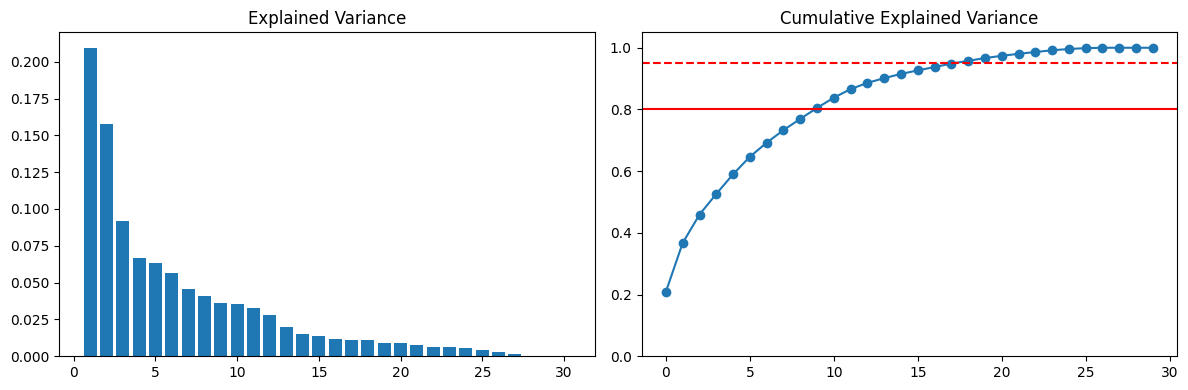

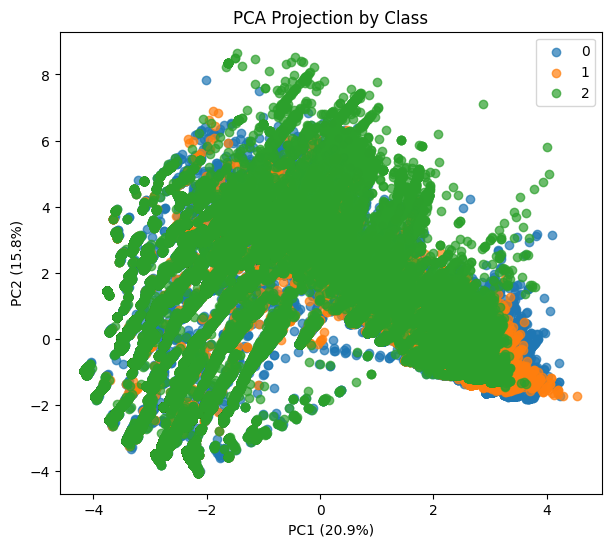

(PCA(),
              PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 0      -2.351053 -3.499183  2.378882  0.153760  0.169683 -0.668898 -2.169197   
 1      -2.322573 -3.578511  2.344869  0.107660  0.036307 -0.560157 -1.715423   
 2      -2.365638 -3.405730  2.118247  0.087757  0.012695 -0.458184 -1.295156   
 3      -2.915604 -3.498221  1.732906  0.060297  0.065702 -0.205894 -0.388789   
 4      -2.789315 -3.208496  1.573586 -0.026540 -0.079522  0.003409  0.206413   
 ...          ...       ...       ...       ...       ...       ...       ...   
 820531  3.232839 -0.740566 -0.198111  1.246099  0.312178 -1.226744  1.568402   
 820532  3.154373 -0.870699 -0.384843 -0.269668  2.691000 -0.429120  1.056224   
 820533  3.158472 -1.067441 -0.703953 -2.234431  5.625066  0.655576  0.270383   
 820534  3.125748 -1.133512 -0.811252 -2.212308  5.630773  0.609510  0.214817   
 820535  2.911324 -0.683340  0.101155 -2.993834  6.057396  1.837386  0.212737   
 
              PC8 

In [3]:
features_set = compute_features(builder_log_based.build())
pca_analysis(features_set.X_train, features_set.y_train)

## Classifaction with Onehot Encoded

Processing cases: 100%|██████████| 6232/6232 [00:07<00:00, 836.11it/s]


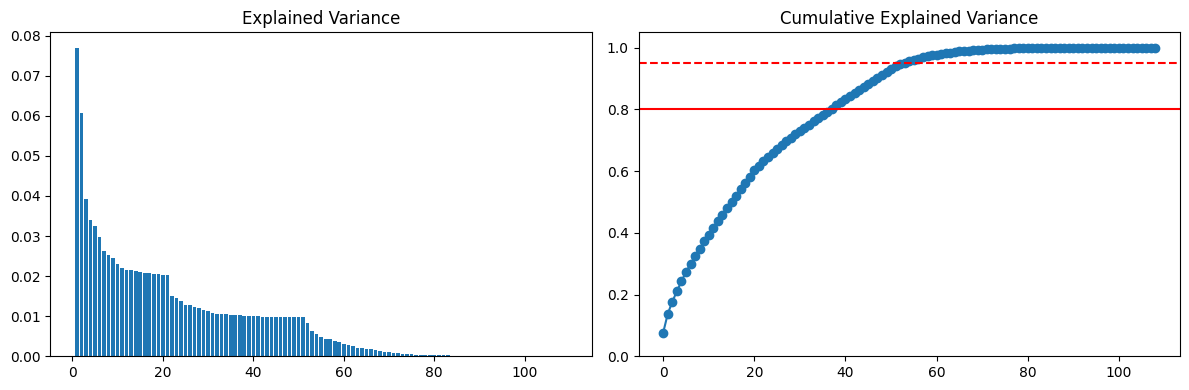

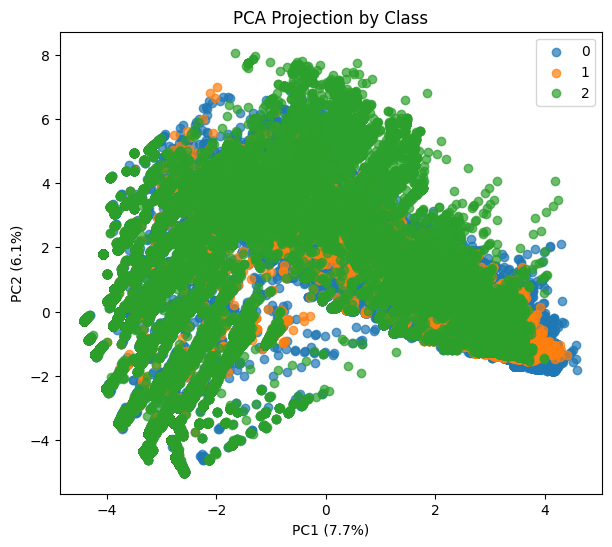

(PCA(),
              PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 0      -2.758191 -4.548512  3.301341 -0.691345  0.105781 -2.428949  4.364780   
 1      -2.728270 -4.634301  3.243639 -0.713297  0.026852 -2.253192  4.013778   
 2      -2.828765 -4.017829  2.001215 -0.352160 -0.045079 -0.598800  0.213727   
 3      -3.346205 -4.353467  2.043472 -0.300668  0.078500 -0.767658  0.579105   
 4      -3.229156 -3.767677  1.408652 -0.163382 -0.099082  0.194143 -1.075072   
 ...          ...       ...       ...       ...       ...       ...       ...   
 820531  3.605289 -0.616311 -0.178622 -0.997083  0.580798 -1.430302 -2.310490   
 820532  3.589640 -1.018653 -0.288264  3.832108  1.965183 -0.841916 -0.447065   
 820533  3.661905 -1.287698 -0.266446  9.609559  4.460052 -1.431509  0.797986   
 820534  3.570487 -1.046192 -0.168745  5.290998  2.936167 -1.579875 -1.101293   
 820535  3.053836 -0.066585  3.032617  7.974041  2.725853  2.254269 -0.361044   
 
              PC8 

In [4]:
features_set = compute_features(builder_log_based_onehot.build())
pca_analysis(features_set.X_train, features_set.y_train)

## Classifaction with Timeseries

Processing cases: 100%|██████████| 6232/6232 [00:09<00:00, 651.43it/s]


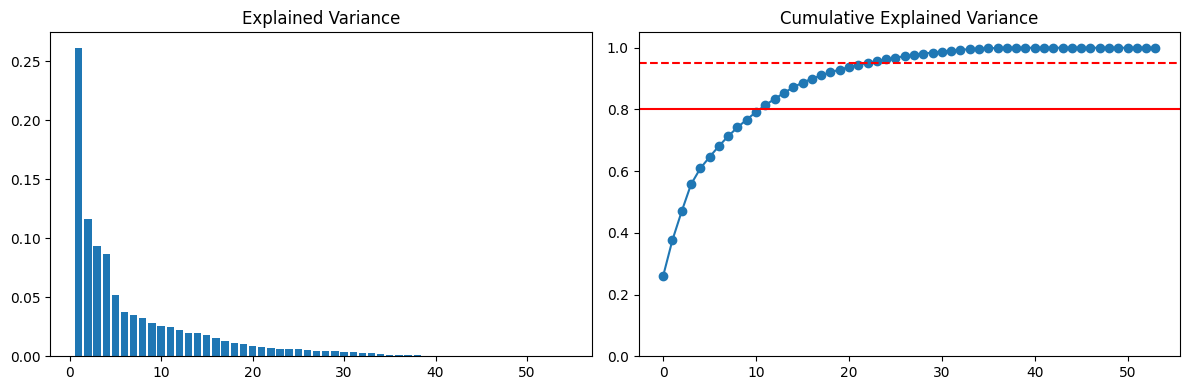

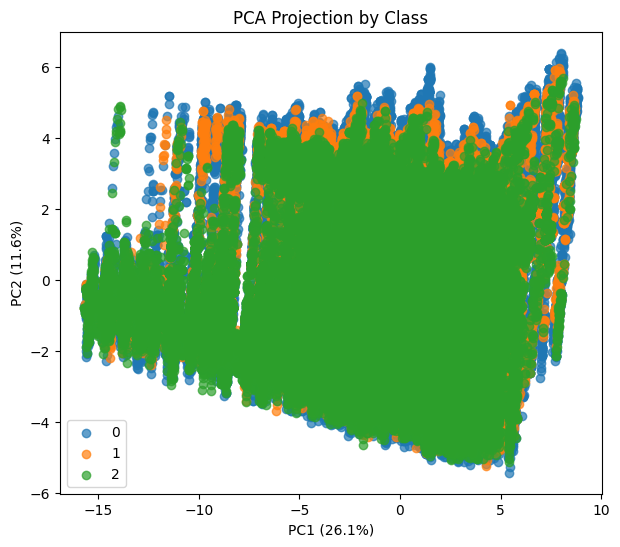

(PCA(),
              PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
 0       2.258730 -3.179825  0.714507 -3.897283  1.910960  0.445601  0.179183   
 1       2.257234 -3.151015  0.700891 -3.975101  1.882689  0.388628  0.060003   
 2       2.248634 -3.187492  0.716626 -3.801736  1.664542  0.351170  0.043950   
 3       2.187553 -3.711498  0.567221 -3.847231  1.317786  0.305125  0.140461   
 4       2.673525 -3.001773 -2.764236 -2.675321  1.592470  0.239952 -0.320978   
 ...          ...       ...       ...       ...       ...       ...       ...   
 820531  5.502574  2.526011  0.690703 -1.049160 -0.430554  1.398549  0.422470   
 820532  5.463271  2.364029  0.598656 -1.187984 -0.598319  0.038612  2.710045   
 820533  5.493422  2.393306  0.314848 -1.310348 -0.775117 -1.803593  5.658115   
 820534  5.483223  2.362993  0.284749 -1.371037 -0.878240 -1.786678  5.663795   
 820535  5.490426  2.143967  0.424721 -0.933580  0.026075 -2.527517  6.063056   
 
              PC8 

In [5]:
features_set = compute_features(builder_timeseries.build())
pca_analysis(features_set.X_train, features_set.y_train)